In [1]:
import os
import re

import glob
import json
from typing import Dict, List, Tuple, Optional, Sequence, Any
from collections import OrderedDict
from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import xarray as xr
import hashlib

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.transforms as mtransforms
from matplotlib.patches import Rectangle

from pcmdi_enso_reader import (
    ENSOMetricReader,
    ENSODiagReader
)

In [2]:
class ENSOMetricSubset:
    def __init__(
        self,
        out: Dict[str, Any],
        metric_collections: Sequence[str],
        met_names: Dict[str, str],
    ):
        self.out = out
        self.metric_collections = list(metric_collections)
        self.met_names = met_names or {}

    @staticmethod
    def _canon(s: str) -> str:
        return str(s).strip().lower()

    def y_names(self) -> List[str]:
        return list(self.out.get("y_names", []))

    def extract_subset(
        self,
        metrics_ordered: "Dict[str, str]",
        which: str = "raw",   # "raw" or "norm"
        *,
        keep_first_duplicate: bool = True,
        debug: bool = False,
        return_out: bool = False,
        include_other_tab: bool = False,   # if True, also include the other tab_* for convenience
    ):
        """
        Returns
        -------
        subset : dict[mc -> masked_array]
        subset_keys : dict[mc -> list[str]]    # canonical ids (your metrics_ordered keys) found
        subset_labels : dict[mc -> list[str]]  # pretty labels aligned with subset_keys
        out_sub : dict (optional)
            Contains:
              - y_names, x_names
              - tab: list[masked_array]  (the selected one: raw OR norm)
              - tab_raw OR tab_norm (matching `which`)
              - ref_info (carried through)
            If include_other_tab=True, also includes the other one.
        """
        if which not in ("raw", "norm"):
            raise ValueError("which must be 'raw' or 'norm'")

        tabs_raw = self.out["tab_raw"]
        tabs_norm = self.out["tab_norm"]
        x_all = self.out["x_names"]

        # canonical-safe pretty-label dict (avoids KeyError due to case differences)
        ordered_pretty_by_canon = {self._canon(k): v for k, v in metrics_ordered.items()}
        want_canon = [self._canon(k) for k in metrics_ordered.keys()]  # requested order

        subset: Dict[str, np.ma.MaskedArray] = {}
        subset_keys: Dict[str, List[str]] = {}
        subset_labels: Dict[str, List[str]] = {}

        # for out_sub (if requested)
        x_sub_all: List[List[str]] = []
        tab_raw_sub_all: List[np.ma.MaskedArray] = []
        tab_norm_sub_all: List[np.ma.MaskedArray] = []

        for k, mc in enumerate(self.metric_collections):
            x = list(x_all[k])         # JSON metric keys in this group
            tab_r = tabs_raw[k]
            tab_n = tabs_norm[k]

            idx_by_canon: Dict[str, int] = {}
            dupes: Dict[str, List[int]] = {}
            jsonkey_by_canon: Dict[str, str] = {}

            for j, met_key in enumerate(x):
                canon_id = self._canon(self.met_names.get(met_key, met_key))
                if canon_id in idx_by_canon:
                    dupes.setdefault(canon_id, [idx_by_canon[canon_id]]).append(j)
                    if not keep_first_duplicate:
                        idx_by_canon[canon_id] = j
                        jsonkey_by_canon[canon_id] = met_key
                else:
                    idx_by_canon[canon_id] = j
                    jsonkey_by_canon[canon_id] = met_key

            # Select columns in requested order
            sub_canon = [cid for cid in want_canon if cid in idx_by_canon]
            cols = [idx_by_canon[cid] for cid in sub_canon]

            sub_tab_raw = tab_r[:, cols]
            sub_tab_norm = tab_n[:, cols]

            sub_pretty = [ordered_pretty_by_canon[cid] for cid in sub_canon]
            sub_json_keys = [jsonkey_by_canon[cid] for cid in sub_canon]

            subset[mc] = sub_tab_raw if which == "raw" else sub_tab_norm
            subset_keys[mc] = sub_canon
            subset_labels[mc] = sub_pretty

            if return_out:
                x_sub_all.append(sub_json_keys)
                tab_raw_sub_all.append(sub_tab_raw)
                tab_norm_sub_all.append(sub_tab_norm)

            if debug:
                missing = [cid for cid in want_canon if cid not in idx_by_canon]
                if missing:
                    print(f"[{mc}] missing {len(missing)} metrics: {missing}")
                if dupes:
                    kept = "first" if keep_first_duplicate else "last"
                    print(f"[{mc}] duplicates (kept {kept}): {dupes}")
                print(f"[{mc}] selected {len(cols)} metrics.")

        if not return_out:
            return subset, subset_keys, subset_labels

        out_sub: Dict[str, Any] = {
            "y_names": list(self.out["y_names"]),
            "ref_info": self.out.get("ref_info", {}),
            "x_names": x_sub_all,
        }

        # unified tab key
        if which == "raw":
            out_sub["tab"] = tab_raw_sub_all
            out_sub["tab_raw"] = tab_raw_sub_all
            if include_other_tab:
                out_sub["tab_norm"] = tab_norm_sub_all
        else:
            out_sub["tab"] = tab_norm_sub_all
            out_sub["tab_norm"] = tab_norm_sub_all
            if include_other_tab:
                out_sub["tab_raw"] = tab_raw_sub_all

        return subset, subset_keys, subset_labels, out_sub


In [3]:
class ENSOOutSubRelativePlotterMulti:
    """
    Like ENSOOutSubRelativePlotter, but supports multiple named E3SM groups.

    rel(model) = |m_model - obs| / mean_{CMIP6} |m_i - obs|

    Required out_sub schema:
      out_sub['y_names'] : list[str]
      out_sub['x_names'] : list[list[str]]        # per metric_collection
      out_sub['tab']     : list[masked_array]     # per metric_collection (already chosen raw/norm)
    """

    def __init__(
        self,
        out_sub: Dict[str, Any],
        *,
        e3sm_groups: Dict[str, str],  # name -> include-regex
        cmip6_exclude_regexes: Sequence[str] = (r"^\(reference\)$", r"^E3SM-", r"^v3-LR-"),
        reference_regex: str = r"^\(reference\)$",
    ):
        self.out = out_sub

        self._re_ref = re.compile(reference_regex)
        self._re_cmip6_excl = [re.compile(p) for p in cmip6_exclude_regexes]
        self._re_groups = {name: re.compile(pat) for name, pat in e3sm_groups.items()}

        self.y_names: List[str] = list(out_sub.get("y_names", []))
        self.group_xnames: List[List[str]] = list(out_sub.get("x_names", []))
        self.group_tabs: List[np.ma.MaskedArray] = list(out_sub.get("tab", []))

        if len(self.group_xnames) != len(self.group_tabs):
            raise ValueError("out_sub['x_names'] and out_sub['tab'] must have same length")

        # --- reference row ---
        idx_ref = [i for i, y in enumerate(self.y_names) if self._re_ref.search(y)]
        if len(idx_ref) != 1:
            raise ValueError(
                f"Expected exactly 1 reference row matching {reference_regex}, got {len(idx_ref)}: {idx_ref}"
            )
        self.idx_ref = idx_ref[0]

        # --- CMIP6 rows ---
        self.idx_cmip6 = [i for i, y in enumerate(self.y_names) if not self._is_cmip6_excluded(y)]
        if len(self.idx_cmip6) == 0:
            raise ValueError("No CMIP6 rows after exclusions; adjust cmip6_exclude_regexes")

        # --- group rows ---
        self.idx_groups: Dict[str, List[int]] = {}
        for name, rr in self._re_groups.items():
            idx = [i for i, y in enumerate(self.y_names) if rr.search(y)]
            if len(idx) == 0:
                raise ValueError(f"No rows matched group '{name}' regex: {rr.pattern}")
            self.idx_groups[name] = idx

    def _is_cmip6_excluded(self, y: str) -> bool:
        return any(r.search(y) for r in self._re_cmip6_excl)

    @staticmethod
    def _canon(s: str) -> str:
        return str(s).strip().lower()

    @staticmethod
    def _masked_to_float(a) -> np.ndarray:
        if isinstance(a, np.ma.MaskedArray):
            return a.astype(float).filled(np.nan)
        return np.asarray(a, dtype=float)

    @staticmethod
    def _bootstrap_ci_mean(
        x: np.ndarray,
        n_mc: int = 5000,
        alpha: float = 0.05,
        seed: int = 0,
    ) -> Tuple[float, float, float]:
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan, np.nan, np.nan
        if x.size == 1:
            m = float(x[0])
            return m, m, m
        rng = np.random.default_rng(seed)
        idx = rng.integers(0, x.size, size=(n_mc, x.size))
        means = x[idx].mean(axis=1)
        m = float(x.mean())
        lo = float(np.percentile(means, 100 * (alpha / 2)))
        hi = float(np.percentile(means, 100 * (1 - alpha / 2)))
        return m, lo, hi

    @staticmethod
    def _mc_ci_mean_t(
        x: np.ndarray,
        n_mc: int = 20000,
        alpha: float = 0.05,
        seed: int = 0,
    ) -> Tuple[float, float, float]:
        """
        Parametric Monte-Carlo CI for the mean.
        Uses t_{n-1} if SciPy is available; otherwise falls back to Normal approx.
        """
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        n = x.size
        if n == 0:
            return np.nan, np.nan, np.nan
        m = float(x.mean())
        if n == 1:
            return m, m, m

        s = float(x.std(ddof=1))
        se = s / np.sqrt(n)
        rng = np.random.default_rng(seed)

        try:
            from scipy.stats import t as tdist
            t_draw = tdist.rvs(df=n - 1, size=n_mc, random_state=rng)
        except Exception:
            # Normal approximation to t (portable fallback)
            t_draw = rng.standard_normal(n_mc)

        mean_draw = m + t_draw * se
        lo = float(np.quantile(mean_draw, alpha / 2))
        hi = float(np.quantile(mean_draw, 1 - alpha / 2))
        return m, lo, hi

    @staticmethod
    def _seed32(base_seed: int, metric_i: int, group: str, method: str) -> int:
        """
        Stable 32-bit seed derived from semantic identifiers (order-independent).
        """
        s = f"{base_seed}|{metric_i}|{group}|{method}".encode("utf-8")
        return int(hashlib.sha256(s).hexdigest()[:8], 16)

    def _flatten_metrics_in_order(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
    ) -> Tuple[List[Tuple[int, int]], List[str]]:
        met_names = met_names or {}

        want_keys = [self._canon(k) for k in metrics_ordered.keys()]
        want_lbls = [metrics_ordered[k] for k in metrics_ordered.keys()]

        where: Dict[str, Tuple[int, int]] = {}
        dupes: Dict[str, List[Tuple[int, int]]] = {}

        for g, xnames in enumerate(self.group_xnames):
            for j, mk in enumerate(xnames):
                cid = self._canon(met_names.get(mk, mk))
                if cid in where:
                    dupes.setdefault(cid, [where[cid]]).append((g, j))
                    if not keep_first_duplicate:
                        where[cid] = (g, j)
                else:
                    where[cid] = (g, j)

        locs, labels, missing = [], [], []
        for cid, lbl in zip(want_keys, want_lbls):
            if cid in where:
                locs.append(where[cid])
                labels.append(lbl)
            else:
                missing.append(cid)

        if debug:
            if missing:
                print(f"[plotter] missing {len(missing)} metrics: {missing}")
            if dupes:
                kept = "first" if keep_first_duplicate else "last"
                print(f"[plotter] duplicates (kept {kept}): {dupes}")

        return locs, labels

    def compute_relative(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
    ) -> Tuple[List[str], np.ndarray, List[np.ndarray], Dict[str, List[np.ndarray]]]:
        locs, labels = self._flatten_metrics_in_order(
            metrics_ordered,
            met_names=met_names,
            keep_first_duplicate=keep_first_duplicate,
            debug=debug,
        )

        n = len(locs)
        denom_arr = np.full(n, np.nan)
        cmip6_rel_list: List[np.ndarray] = []
        group_rel: Dict[str, List[np.ndarray]] = {k: [] for k in self.idx_groups.keys()}

        for i, (g, j) in enumerate(locs):
            tab = self._masked_to_float(self.group_tabs[g])

            obs = tab[self.idx_ref, j]
            cm = tab[self.idx_cmip6, j]

            d_cm = np.abs(cm - obs)
            d_cm = d_cm[np.isfinite(d_cm)]
            denom = float(np.nanmean(d_cm)) if d_cm.size else np.nan
            denom_arr[i] = denom

            if not np.isfinite(denom) or denom == 0:
                cm_rel = np.full_like(cm, np.nan, dtype=float)
            else:
                cm_rel = np.abs(cm - obs) / denom
            cmip6_rel_list.append(cm_rel)

            for name, idx in self.idx_groups.items():
                ee = tab[idx, j]
                if not np.isfinite(denom) or denom == 0:
                    ee_rel = np.full_like(ee, np.nan, dtype=float)
                else:
                    ee_rel = np.abs(ee - obs) / denom
                group_rel[name].append(ee_rel)

        return labels, denom_arr, cmip6_rel_list, group_rel

    def list_models(self) -> Dict[str, List[str]]:
        out: Dict[str, List[str]] = {}
        out["CMIP6"] = [self.y_names[i] for i in self.idx_cmip6]
        for gname, idxs in self.idx_groups.items():
            out[gname] = [self.y_names[i] for i in idxs]
        return out

    def _add_metric_category_bands(
        self,
        ax,
        labels: List[str],
        category_spec: List[Tuple[str, List[str], str]],
        *,
        bottom_y0: float = -0.34,   # axes fraction (below axis)
        bottom_h: float = 0.16,
        top_y0: float = 0.985,
        top_h: float = 0.02,
        draw_top_strip: bool = True,
        alpha: float = 0.35,
        zorder: int = 0,
    ):
        """
        Draw colored category shading aligned with x positions.
    
        category_spec: [(name, [match_keys...], color), ...]
          - match_keys are substrings matched against tick labels
          - assumes your metric ordering makes each category mostly contiguous
        """
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    
        def _match(label: str, keys: List[str]) -> bool:
            lab = str(label)
            return any(k in lab for k in keys)
    
        for _cat, keys, color in category_spec:
            idx = [i for i, lab in enumerate(labels) if _match(lab, keys)]
            if not idx:
                continue
            idx = sorted(idx)
    
            # contiguous runs
            runs = []
            s = p = idx[0]
            for ii in idx[1:]:
                if ii == p + 1:
                    p = ii
                else:
                    runs.append((s, p))
                    s = p = ii
            runs.append((s, p))
    
            for s, p in runs:
                x0 = s - 0.5
                w = (p - s + 1)
    
                ax.add_patch(Rectangle(
                    (x0, bottom_y0), w, bottom_h,
                    transform=trans,
                    facecolor=color, edgecolor="none",
                    alpha=alpha, zorder=zorder,
                    clip_on=False,
                ))
    
                if draw_top_strip:
                    ax.add_patch(Rectangle(
                        (x0, top_y0), w, top_h,
                        transform=trans,
                        facecolor=color, edgecolor="none",
                        alpha=0.9, zorder=zorder,
                        clip_on=False,
                    ))
                    
    def _label_color_from_category(self, label: str, category_spec):
        for _cat, keys, color in category_spec:
            if any(k in label for k in keys):
                return color
        return None
        
    def _label_color(self, label: str, category_spec):
        for _cat, keys, color in category_spec:
            if any(k in label for k in keys):
                return color
        return None
    
    def plot(
        self,
        metrics_ordered: "Dict[str, str]",
        *,
        met_names: Optional[Dict[str, str]] = None,
        title: str = "Metric values relative to observations (CMIP6-normalized)",
        show_cmip6_models: bool = False,
        show_groups_members: bool = False,
        show_means_and_ci: bool = True,
        n_mc: int = 5000,
        alpha: float = 0.05,
        figsize: Tuple[float, float] = (13.5, 4.6),
        dpi: int = 160,
        dodge: float = 0.18,
        x_label_rotation: float = 45,
        y_lim: Optional[Tuple[float, float]] = None,
        y_label: str = "Normalized distance to OBS (0=OBS, 1=CMIP6 mean)",
        # styles
        color_cmip6: str = "tab:red",
        group_styles: Optional[Dict[str, Dict[str, Any]]] = None,
        keep_first_duplicate: bool = True,
        debug: bool = False,
        fontz: float = 12,
        bootstrap_ci: bool = False,
        base_seed: int = 20260218,
        ci_legend_label: str = r"multi-model mean $\pm$ 95\% CI (across models)",
        category_spec: Optional[List[Tuple[str, List[str], str]]] = None,
        category_band_alpha: float = 0.35,
        category_draw_top_strip: bool = True,
    ):
        
        labels, _denom, cmip6_rel_list, group_rel = self.compute_relative(
            metrics_ordered,
            met_names=met_names,
            keep_first_duplicate=keep_first_duplicate,
            debug=debug,
        )
        
        group_styles = group_styles or {}
        group_names = list(group_rel.keys())
        n = len(labels)   # <-- add this
        x = np.arange(n, dtype=float)

        print("CMIP6 n =", len(self.idx_cmip6))
        for gn in group_names:
            print(f"{gn} n =", len(self.idx_groups[gn]), "example:", self.y_names[self.idx_groups[gn][0]])
        
            counts = np.array([np.isfinite(group_rel[gn][i]).sum() for i in range(n)], int)
            bad = np.where(counts < 2)[0]
        
            print(f"[{gn}] finite counts min/median/max = {counts.min()}/{np.median(counts)}/{counts.max()}")
        
            if bad.size:
                print(f"  metrics with <2 finite values: {bad.size}/{n} (first 10 idx) {bad[:10].tolist()}")
                print("  first few labels:", [labels[ii] for ii in bad[:5]])
        
                
        # precompute means/CI
        cm_mean = np.full(n, np.nan)
        cm_ci = np.full((n, 2), np.nan)
        g_mean: Dict[str, np.ndarray] = {gn: np.full(n, np.nan) for gn in group_names}
        g_ci: Dict[str, np.ndarray] = {gn: np.full((n, 2), np.nan) for gn in group_names}

        if show_means_and_ci:
            method = "bootstrap" if bootstrap_ci else "mc_t"

            for i in range(n):
                seed_cm = self._seed32(base_seed, i, "CMIP6", method)

                if bootstrap_ci:
                    m, lo, hi = self._bootstrap_ci_mean(
                        cmip6_rel_list[i], n_mc=n_mc, alpha=alpha, seed=seed_cm
                    )
                else:
                    m, lo, hi = self._mc_ci_mean_t(
                        cmip6_rel_list[i], n_mc=n_mc, alpha=alpha, seed=seed_cm
                    )
                cm_mean[i], cm_ci[i, 0], cm_ci[i, 1] = m, lo, hi

                for gn in group_names:
                    seed_g = self._seed32(base_seed, i, gn, method)
                    nmc_g = min(n_mc, 3000)

                    if bootstrap_ci:
                        m, lo, hi = self._bootstrap_ci_mean(
                            group_rel[gn][i], n_mc=nmc_g, alpha=alpha, seed=seed_g
                        )
                    else:
                        m, lo, hi = self._mc_ci_mean_t(
                            group_rel[gn][i], n_mc=nmc_g, alpha=alpha, seed=seed_g
                        )
                    g_mean[gn][i], g_ci[gn][i, 0], g_ci[gn][i, 1] = m, lo, hi
                    
        if show_means_and_ci:
            for gn in group_names:
                widths = []
                for i in range(n):
                    lo, hi = g_ci[gn][i, 0], g_ci[gn][i, 1]
                    if np.isfinite(lo) and np.isfinite(hi):
                        widths.append(hi - lo)
                widths = np.array(widths)
                print(gn, "CI width median =", np.nanmedian(widths), "min =", np.nanmin(widths), "count =", widths.size)
                
        # y-lims
        if y_lim is None:
            pts = []
            pts += [a for a in cmip6_rel_list if np.asarray(a).size]
            for gn in group_names:
                pts += [a for a in group_rel[gn] if np.asarray(a).size]
            pts = np.concatenate([np.asarray(p, float).ravel() for p in pts], axis=0) if pts else np.array([1.0])
            finite = pts[np.isfinite(pts)]
            if finite.size:
                lo = float(np.nanpercentile(finite, 2))
                hi = float(np.nanpercentile(finite, 98))
                pad = 0.15 * (hi - lo + 1e-9)
                y_lim = (max(0.0, lo - pad), hi + pad)
            else:
                y_lim = (0.0, 2.0)

        fig = plt.figure(figsize=figsize, dpi=dpi)
        #ax = fig.add_axes([0.06, 0.18, 0.92, 0.72])
        ax = fig.add_axes([0.06, 0.26, 0.92, 0.64])


        ax.axhline(0.0, lw=1.0, color="k", alpha=0.35)
        ax.axhline(1.0, lw=1.2, color="k", alpha=0.6)
        ax.axhline(2.0, lw=0.8, ls="--", color="k", alpha=0.35)

        # offsets for groups (centered)
        if len(group_names) == 1:
            offsets = {group_names[0]: dodge}
        else:
            span = dodge * (len(group_names) - 1)
            offsets = {gn: (-0.5 * span + i * dodge) for i, gn in enumerate(group_names)}

        # clouds
        h_cm_cloud = None
        if show_cmip6_models:
            for i, arr in enumerate(cmip6_rel_list):
                arr = np.asarray(arr, float)
                arr = arr[np.isfinite(arr)]
                if arr.size == 0:
                    continue
                h = ax.scatter(
                    np.full(arr.shape, x[i]),
                    arr,
                    marker="o",
                    s=25,
                    alpha=0.1,
                    color=color_cmip6,
                    edgecolors="none",
                    zorder=2,
                )
                if h_cm_cloud is None:
                    h_cm_cloud = h

        h_group_cloud: Dict[str, Any] = {}
        if show_groups_members:
            for gn in group_names:
                st = group_styles.get(gn, {})
                c = st.get("color", None)
                mk = st.get("marker", "o")
                ss = st.get("s", 25)
                aa = st.get("alpha", 0.10)
                for i, arr in enumerate(group_rel[gn]):
                    arr = np.asarray(arr, float)
                    arr = arr[np.isfinite(arr)]
                    if arr.size == 0:
                        continue
                    h = ax.scatter(
                        np.full(arr.shape, x[i]) + offsets[gn],
                        arr,
                        marker=mk,
                        s=ss,
                        alpha=aa,
                        color=c,
                        edgecolors="none",
                        zorder=3,
                    )
                    if gn not in h_group_cloud:
                        h_group_cloud[gn] = h

        # means + CI
        h_cm_mean = None
        if show_means_and_ci:
            for i in range(n):
                m, lo, hi = cm_mean[i], cm_ci[i, 0], cm_ci[i, 1]
                if np.isfinite(m) and np.isfinite(lo) and np.isfinite(hi):
                    h = ax.errorbar(
                        x[i], m,
                        yerr=[[m - lo], [hi - m]],
                        fmt="D",
                        markersize=10,
                        capsize=5,
                        elinewidth=1.5,
                        color=color_cmip6,
                        zorder=5,
                    )
                    if h_cm_mean is None:
                        h_cm_mean = h

            h_group_mean: Dict[str, Any] = {}
            for gn in group_names:
                st = group_styles.get(gn, {})
                c = st.get("color", None)
                for i in range(n):
                    m, lo, hi = g_mean[gn][i], g_ci[gn][i, 0], g_ci[gn][i, 1]
                    if np.isfinite(m) and np.isfinite(lo) and np.isfinite(hi):
                        h = ax.errorbar(
                            x[i] + offsets[gn], m,
                            yerr=[[m - lo], [hi - m]],
                            fmt=st.get("mean_marker", "s"),
                            markersize=st.get("mean_markersize",10),
                            capsize=5,
                            elinewidth=1.5,
                            color=c,
                            zorder=6,
                        )
                        if gn not in h_group_mean:
                            h_group_mean[gn] = h

        ax.set_title(title, fontsize=fontz * 1.0, pad=8,loc="left")
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(*y_lim)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=x_label_rotation, ha="right", fontsize=fontz * 0.95)
                
        if category_spec:
            for t in ax.get_xticklabels():
                lab = t.get_text()
                c = self._label_color_from_category(lab, category_spec)
                if c is None:
                    continue
                t.set_bbox(dict(
                    facecolor=c,
                    edgecolor="none",
                    alpha=0.45,
                    pad=2.5,   # size of the tile
                ))
                
        # --- axis shading strips (top + bottom ribbons) ---
        if category_spec:
            
            trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        
            def _cat_id(label: str):
                for ic, (_cat, keys, _c) in enumerate(category_spec):
                    if any(k in label for k in keys):
                        return ic
                return None
        
            def _cat_color_from_id(cid: int):
                return category_spec[cid][2]
        
            cat_ids = [_cat_id(lab) for lab in labels]
        
            # tune these
            y0_top, h_top = 0.985, 0.015
            y0_bot, h_bot = 0.0,   0.015   # <-- ON the x-axis line

            i = 0
            while i < len(labels):
                if cat_ids[i] is None:
                    i += 1
                    continue
                j = i
                while j + 1 < len(labels) and cat_ids[j + 1] == cat_ids[i]:
                    j += 1
        
                c = _cat_color_from_id(cat_ids[i])
        
                # top ribbon
                ax.add_patch(Rectangle(
                    (i - 0.5, y0_top), (j - i + 1), h_top,
                    transform=trans,
                    facecolor=c, edgecolor="none",
                    alpha=0.9, zorder=0,
                    clip_on=False,
                ))
        
                # bottom ribbon
                ax.add_patch(Rectangle(
                    (i - 0.5, y0_bot), (j - i + 1), h_bot,
                    transform=trans,
                    facecolor=c, edgecolor="none",
                    alpha=0.9, zorder=0,
                    clip_on=False,
                ))
        
                i = j + 1

        
        # --- y-axis styling (improved vs worsened) ---
        ax.set_ylim(0.0, max(ax.get_ylim()[1], 2.0))
        ax.set_ylabel(y_label, fontsize=fontz * 0.95)
        ax.set_yticks(np.linspace(0, 2.0, 5))
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=6, labelsize=fontz * 0.95)
        ax.axhline(0.5, lw=0.8, ls="--", color="0.6", alpha=0.6, zorder=1)
        ax.axhline(1.5, lw=0.8, ls="--", color="0.6", alpha=0.6, zorder=1)

        # --- improved / worsened arrows ---
        x_arrow = -0.06
        y_top = 0.95
        y_bot = 0.05
        y_mid = 0.5 * (y_top + y_bot)

        ax.annotate(
            "", xy=(x_arrow, y_top), xytext=(x_arrow, y_mid + 0.05),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.5, color="k"),
            annotation_clip=False,
        )
        ax.annotate(
            "", xy=(x_arrow, y_bot), xytext=(x_arrow, y_mid - 0.05),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.5, color="k"),
            annotation_clip=False,
        )

        ax.text(
            x_arrow - 0.02, y_top - 0.05,
            "worsened",
            transform=ax.transAxes,
            rotation=90, va="top", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow - 0.02, y_bot + 0.05,
            "improved",
            transform=ax.transAxes,
            rotation=90, va="bottom", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )

        ax.text(
            x_arrow + 0.0, 1.0,
            r"2$\times$CMIP6",
            transform=ax.transAxes,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow + 0.0, y_mid,
            "CMIP6",
            transform=ax.transAxes,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )
        ax.text(
            x_arrow + 0.0, 0.0,
            "Reference",
            transform=ax.transAxes,
            va="center", ha="center",
            clip_on=False,
            fontsize=fontz * 0.95,
        )

        # --- whisker legend (CI) ---
        whisker_handle = ax.errorbar(
            [np.nan], [np.nan],
            yerr=[[0.45], [0.45]],
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
        )

        leg_whisker = ax.legend(
            handles=[whisker_handle],
            labels=[ci_legend_label],
            frameon=False,
            handletextpad=0.15,
            labelspacing=0.2,
            handlelength=1.0,
            fontsize=fontz * 0.95,
        )
        ax.add_artist(leg_whisker)

        # --- color legend (model families) as text ---
        x0, y0 = 0.75, 0.25
        dy = 0.10

        ax.text(
            x0, y0,
            f"CMIP6 ({len(self.idx_cmip6)})",
            transform=ax.transAxes,
            ha="right", va="top",
            color=color_cmip6,
            fontsize=fontz * 0.95,
            fontweight="bold",
        )

        n_e3sm_total = sum(len(v) for v in self.idx_groups.values())
        e3sm_color = group_styles.get(list(self.idx_groups.keys())[0], {}).get("color", "C3")

        ax.text(
            x0, y0 - dy,
            f"E3SM ({n_e3sm_total})",
            transform=ax.transAxes,
            ha="right", va="top",
            color=e3sm_color,
            fontsize=fontz * 0.95,
            fontweight="bold",
        )

        return fig, ax



=== Reference row check (RAW, before subsetting) ===
[ENSO_perf] n=15  n_nan=0  n_zero=15  min=0  max=0
[ENSO_tel] n=15  n_nan=0  n_zero=15  min=0  max=0
[ENSO_proc] n=11  n_nan=0  n_zero=11  min=0  max=0
[ENSO_perf] missing 9 metrics: ['djf_pr_teleconnection', 'jja_pr_teleconnection', 'djf_ts_teleconnection', 'jja_ts_teleconnection', 'sst-taux_feedback', 'taux-ssh_feedback', 'ssh-sst_feedback', 'sst-nhf_feedback', 'ocean_driven_sst']
[ENSO_perf] selected 15 metrics.
[ENSO_tel] missing 17 metrics: ['double_itcz_bias', 'eq_pr_bias', 'eq_sst_bias', 'eq_taux_bias', 'double_itcz_sea_cycle', 'eq_pr_sea_cycle', 'eq_sst_sea_cycle', 'eq_taux_sea_cycle', 'enso_lifecycle', 'enso_asymmetry', 'enso_duration', 'enso_diversity', 'sst-taux_feedback', 'taux-ssh_feedback', 'ssh-sst_feedback', 'sst-nhf_feedback', 'ocean_driven_sst']
[ENSO_tel] selected 7 metrics.
[ENSO_proc] missing 13 metrics: ['double_itcz_bias', 'eq_pr_bias', 'double_itcz_sea_cycle', 'eq_pr_sea_cycle', 'eq_sst_sea_cycle', 'eq_taux_s

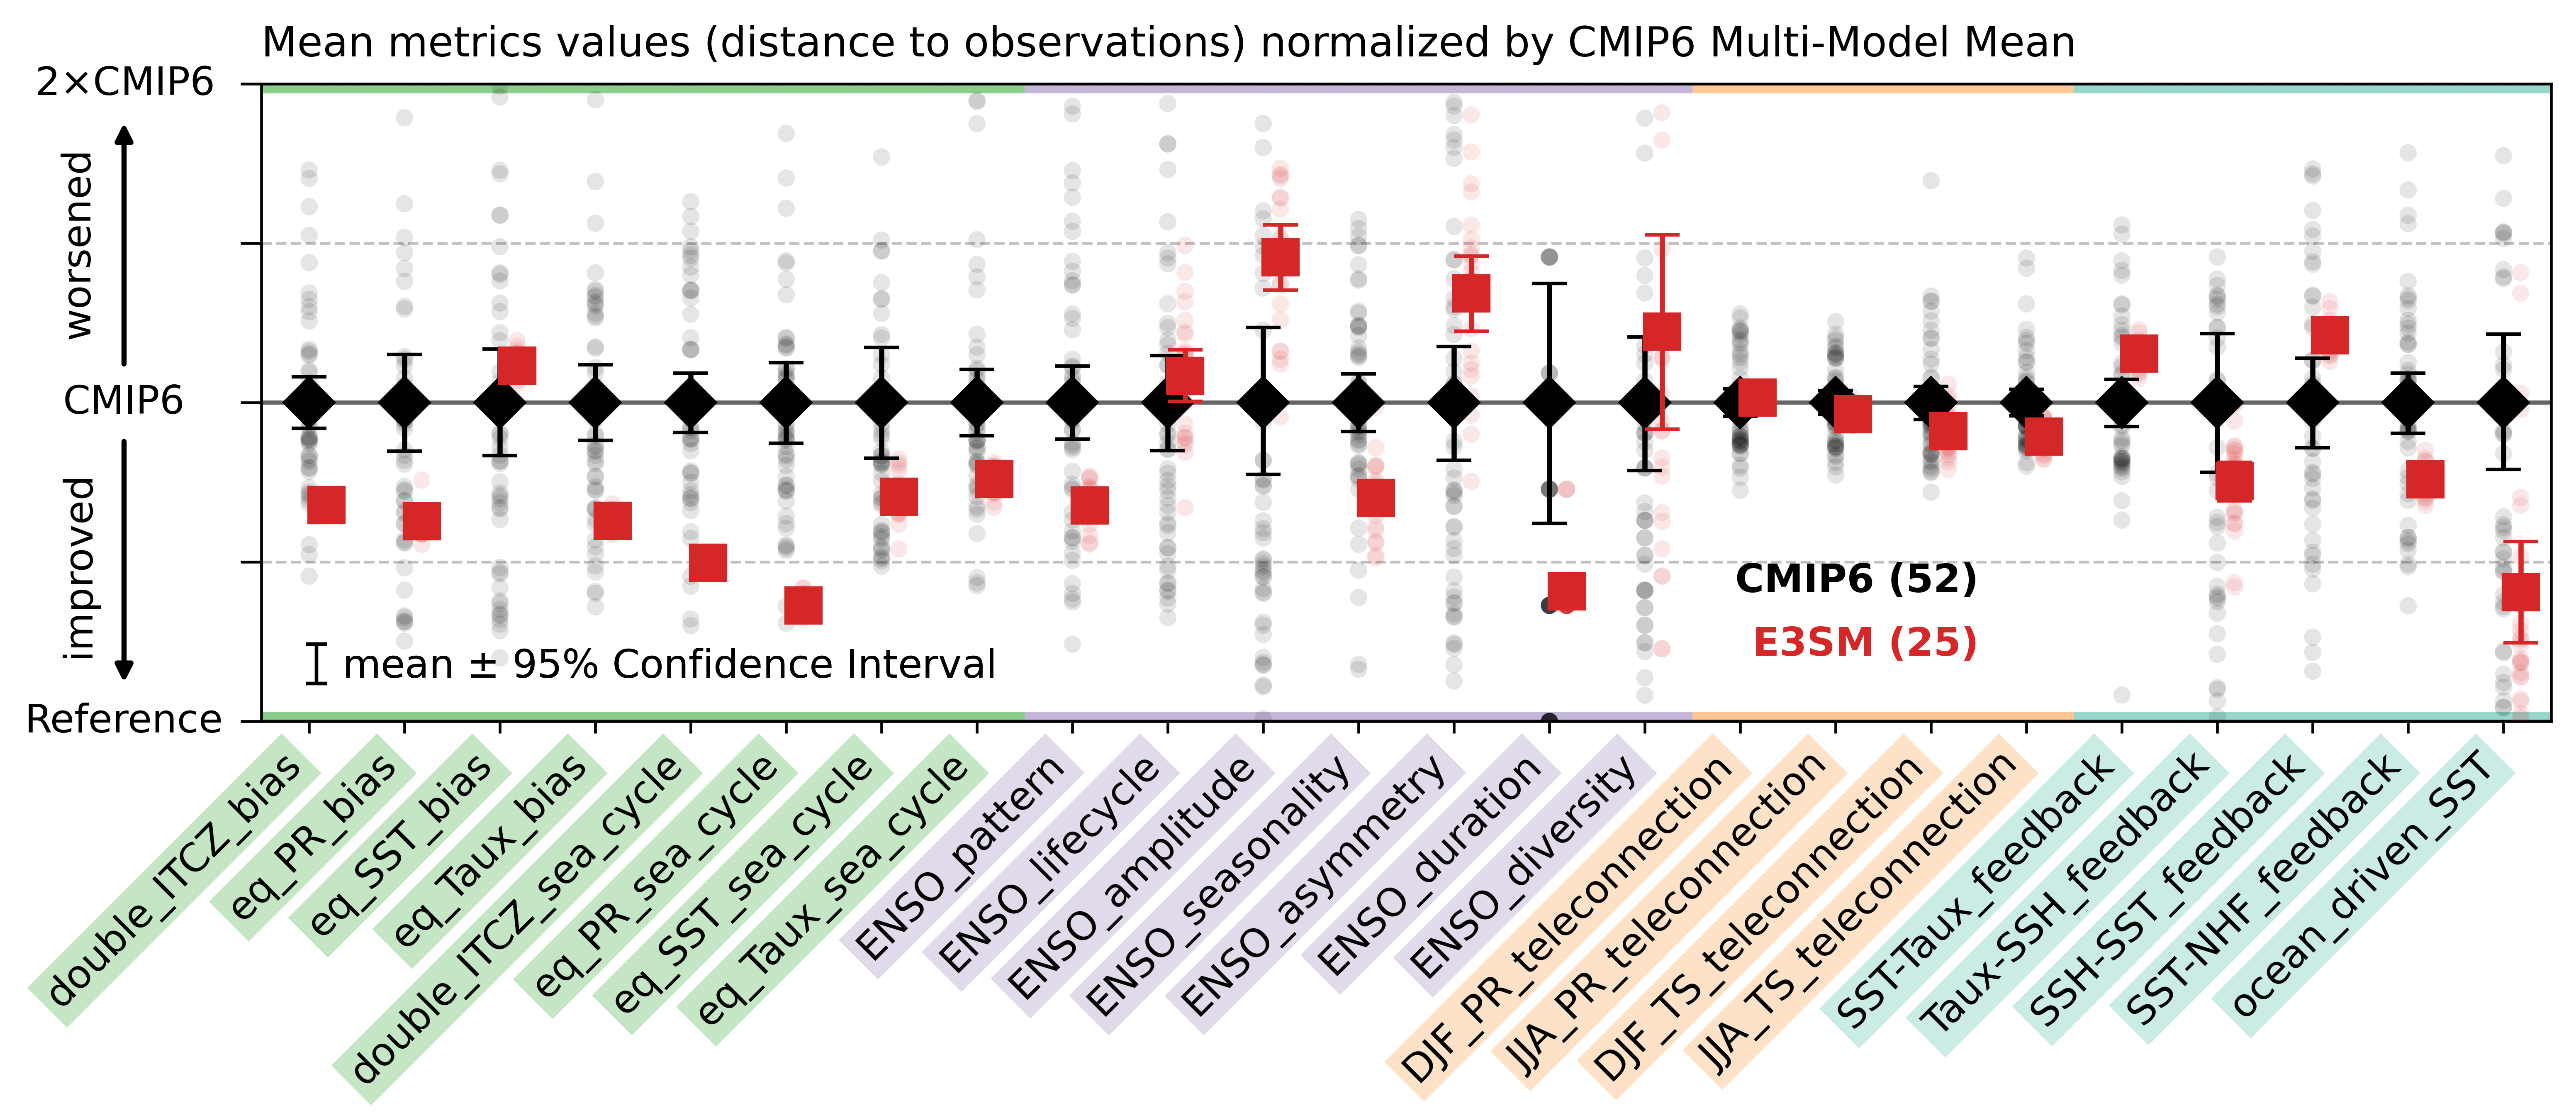

In [4]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    metric_collections = ["ENSO_perf", "ENSO_tel", "ENSO_proc"]

    exp_dict = {
        "CMIP6": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "cmip6.historical.v20210620",
        },
        "E3SMv3-CLIM": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.climo.v20260212",
        },
        "E3SMv3-HIST": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.historical.v20260212",
        },
        "E3SMv3-FUTURE": {
            "dir": "/lcrc/group/e3sm/diagnostics/pcmdi_data/metrics_data/enso_metric",
            "set": "e3sm.future.v20260212",
        },
    }

    # --- choose what to read ---
    list_project = ["CMIP6", "E3SMv3-CLIM"]
    list_obs = ["Tropflux", "Tropflux"]
    mod_order = "predefined"
    show_ref_row = True

    # -----------------------------
    # dict_json_path[proj][coll] = "/path/to/file.json"
    # -----------------------------
    dict_json_path = {}
    for proj in list_project:
        dict_json_path[proj] = {}
        mip, rel, cid = exp_dict[proj]["set"].split(".")
        dpath = exp_dict[proj]["dir"]

        for coll in metric_collections:
            fdir = os.path.join(dpath, mip, rel, cid, coll)
            files = glob.glob(os.path.join(fdir, "*.json"))
            if len(files) == 0:
                raise FileNotFoundError(f"No JSON files found under: {fdir}")
            files = sorted(files, key=os.path.getmtime)   # newest last
            dict_json_path[proj][coll] = files[-1]

    # -----------------------------
    # read metrics
    # -----------------------------
    reader = ENSOMetricReader(
        metric_collections=metric_collections,
        list_project=list_project,
        dict_json_path=dict_json_path,
        list_obs=list_obs,
        mod_order=mod_order,
        show_ref_row=show_ref_row,
    )
    out = reader.read_metrics(return_raw=True)
    _metric_groups, met_names = reader.load_met_names()

    # quick debug so regex can be correct
    #print("First 40 y_names:")
    #for s in out["y_names"][:40]:
    #    print("  ", s)

    # -----------------------------
    # choose subset + order
    # -----------------------------
    metrics_ordered = OrderedDict([
        ("double_ITCZ_bias", "double_ITCZ_bias"),
        ("eq_PR_bias", "eq_PR_bias"),
        ("eq_SST_bias", "eq_SST_bias"),
        ("eq_Taux_bias", "eq_Taux_bias"),
    
        ("double_ITCZ_sea_cycle", "double_ITCZ_sea_cycle"),
        ("eq_PR_sea_cycle", "eq_PR_sea_cycle"),
        ("eq_SST_sea_cycle", "eq_SST_sea_cycle"),
        ("eq_Taux_sea_cycle", "eq_Taux_sea_cycle"),
    
        ("ENSO_pattern", "ENSO_pattern"),
        ("ENSO_lifecycle", "ENSO_lifecycle"),
        ("ENSO_amplitude", "ENSO_amplitude"),
        ("ENSO_seasonality", "ENSO_seasonality"),
        ("ENSO_asymmetry", "ENSO_asymmetry"),
        ("ENSO_duration", "ENSO_duration"),
        ("ENSO_diversity", "ENSO_diversity"),
    
        ("DJF_PR_teleconnection", "DJF_PR_teleconnection"),
        ("JJA_PR_teleconnection", "JJA_PR_teleconnection"),
        ("DJF_TS_teleconnection", "DJF_TS_teleconnection"),
        ("JJA_TS_teleconnection", "JJA_TS_teleconnection"),
    
        ("SST-Taux_feedback", "SST-Taux_feedback"),
        ("Taux-SSH_feedback", "Taux-SSH_feedback"),
        ("SSH-SST_feedback", "SSH-SST_feedback"),
        ("SST-NHF_feedback", "SST-NHF_feedback"),
        ("ocean_driven_SST", "ocean_driven_SST"),
    ])

    category_spec = [
        ("mean state bias", ["bias"], "#7fc97f"),
        ("seasonal cycle", ["sea_cycle"], "#7fc97f"),
        ("ENSO", ["ENSO"], "#beaed4"),
        ("teleconnection", ["teleconnection"], "#fdc086"),
        ("feedback", ["feedback"], "#8dd3c7"),
        ("ocean-driven", ["ocean_driven"], "#8dd3c7"),
    ]

    subsetter = ENSOMetricSubset(
        out=out,
        metric_collections=metric_collections,
        met_names=met_names,
    )

    # -----------------------------
    # NEW: check '(reference)' row values (raw) for zeros/NaNs
    # -----------------------------
    if "(reference)" not in out["y_names"]:
        raise ValueError("'(reference)' not found in out['y_names']; check show_ref_row/list_obs.")
    iref = out["y_names"].index("(reference)")
    print("\n=== Reference row check (RAW, before subsetting) ===")
    for k, coll in enumerate(metric_collections):
        tab = out["tab_raw"][k]
        tab = tab.astype(float).filled(np.nan) if isinstance(tab, np.ma.MaskedArray) else np.asarray(tab, float)
        ref_vals = tab[iref, :]
        n_nan  = int(np.sum(~np.isfinite(ref_vals)))
        n_zero = int(np.sum(np.isfinite(ref_vals) & (ref_vals == 0.0)))
        print(f"[{coll}] n={ref_vals.size}  n_nan={n_nan}  n_zero={n_zero}  "
              f"min={np.nanmin(ref_vals):.3g}  max={np.nanmax(ref_vals):.3g}")

    # -----------------------------
    # subset
    # -----------------------------
    subset_raw, subset_keys, subset_labels, out_sub = subsetter.extract_subset(
        metrics_ordered,
        which="raw",
        debug=True,
        return_out=True,
    )

    # quick sanity
    print("\nmetric_collections:", metric_collections)
    print("x_names lengths:", [len(x) for x in out_sub["x_names"]])
    print("tab shapes:", [t.shape for t in out_sub["tab"]])

    # -----------------------------
    # OPTIONAL: check '(reference)' after subsetting too
    # -----------------------------
    iref_sub = out_sub["y_names"].index("(reference)")
    print("\n=== Reference row check (RAW, after subsetting) ===")
    for k, coll in enumerate(metric_collections):
        tab = out_sub["tab"][k]
        tab = tab.astype(float).filled(np.nan) if isinstance(tab, np.ma.MaskedArray) else np.asarray(tab, float)
        ref_vals = tab[iref_sub, :]
        n_nan  = int(np.sum(~np.isfinite(ref_vals)))
        n_zero = int(np.sum(np.isfinite(ref_vals) & (ref_vals == 0.0)))
        print(f"[{coll}] n={ref_vals.size}  n_nan={n_nan}  n_zero={n_zero}  "
              f"min={np.nanmin(ref_vals):.3g}  max={np.nanmax(ref_vals):.3g}")

    # -----------------------------
    # plot (unchanged)
    # -----------------------------
    title="Mean metrics values (distance to observations) normalized by CMIP6 Multi-Model Mean"
    color_cmip6 = "black" #"tab:red",

    e3sm_groups={
        "E3SMv3-CLIM": r"^(v3-LR)",
        #"E3SMv3-HIST": r"^E3SMv3-HIST",
        #"E3SMv3-FUTURE": r"^E3SMv3-FUTURE",
    }
    group_styles={
        "E3SMv3-CLIM":   {"color": "tab:red"},
        #"E3SMv3-HIST":   {"color": "C0"},
        #"E3SMv3-FUTURE": {"color": "C2"},
    }
    cmip6_exclude_regexes=(r"^\(.*\)$", r"^(E3SM|v3-LR)") 

    show_cmip6_models=True
    show_groups_members=True
    show_means_and_ci=True
    dodge=0.18
    figsize=(10,4)
    dpi=600
    fontz=12
    y_lim=(0,2)
    y_label=""
    ci_legend_label=r"mean $\pm$ 95% Confidence Interval"
    
    plotter = ENSOOutSubRelativePlotterMulti(
        out_sub=out_sub,
        e3sm_groups=e3sm_groups,
        cmip6_exclude_regexes=cmip6_exclude_regexes,
    )

    models = plotter.list_models()
    
    print("\n=== CMIP6 models ===")
    for m in models["CMIP6"]:
        print(m)
    
    for gname in plotter.idx_groups.keys():
        print(f"\n=== {gname} members ===")
        for m in models[gname]:
            print(m)
            
    fig, ax = plotter.plot(
        metrics_ordered=metrics_ordered,
        met_names=met_names,
        title=title,
        show_cmip6_models=show_cmip6_models,
        show_groups_members=show_groups_members,
        show_means_and_ci=show_means_and_ci,
        category_spec=category_spec,
        dodge=dodge,
        color_cmip6=color_cmip6,
        group_styles=group_styles,
        y_lim=y_lim,
        y_label=y_label,
        ci_legend_label=ci_legend_label,
        figsize=figsize,
        fontz=fontz,
        dpi=dpi,
    )

    out_name = os.path.join(FIG_DIR, "E3SMv3_vs_CMIP6_relative.pdf")
    fig.savefig(out_name, bbox_inches="tight", dpi=200)
    print("Wrote:", out_name)
